In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [1]:
from typing_extensions import Literal 
from langchain.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph , START, END, MessagesState
from langgraph.types import Command
from langchain_core.messages import BaseMessage, HumanMessage
from langchain.agents import create_agent
from typing import Annotated
from langchain_experimental.utilities import PythonREPL

In [88]:
llm = ChatGroq(model="moonshotai/kimi-k2-instruct-0905")
# llm=ChatGroq(model='meta-llama/llama-4-scout-17b-16e-instruct')

In [23]:
llm.invoke('hi')

AIMessage(content='Hi! What can I help you with today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 27, 'total_tokens': 38, 'completion_time': 0.027450662, 'completion_tokens_details': None, 'prompt_time': 0.047925939, 'prompt_tokens_details': None, 'queue_time': 2.324460665, 'total_time': 0.075376601}, 'model_name': 'moonshotai/kimi-k2-instruct-0905', 'system_fingerprint': 'fp_241bc7119c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d3f59-d98c-7851-8fcb-956d73c6f0f5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 27, 'output_tokens': 11, 'total_tokens': 38})

In [4]:
from langchain_community.tools import DuckDuckGoSearchRun
DuckDuckGo_web_search_tool = DuckDuckGoSearchRun()

In [5]:
DuckDuckGo_web_search_tool.invoke("What is the GDP of India?")

'63 million MSMEs inIndiawhich contribute 35% to the country\'sGDPprovides employment to 111.4 million persons and accounts for more than 40%ofIndia\'s exports and are hailed as the \'growth engines\' of the economy. GrossDomesticProduct(GDP)isthetotal monetary value of all goods and services produced and sold within a country over one year. (Learn more). Nominal (or "Current")GDPreflects current prices and exchange rates, without adjustments for inflation or cost-of-living differences. TheGrossDomesticProduct(GDP) inIndiawas worth 3912.69 billion US dollars in 2024, according to official data from the World Bank.TheGDPvalueofIndiarepresents 3.69 percent of the world economy. According to the World Bank, sector-wiseIndianGDPcomposition in 2023 is as follows: Agricultural (15.57%), Industry (25.01%), and Services (49.80%). With the production of agricultural activity of $567 billion,Indiaisthe2nd largest producer of agriculturalproducts. India’s economyisthefifth-largest in the world wi

In [6]:
from langchain_community.tools.tavily_search import TavilySearchResults

Tavily_web_search_tool = TavilySearchResults()

C:\Users\USER\AppData\Local\Temp\ipykernel_24176\2799019176.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  Tavily_web_search_tool = TavilySearchResults()


In [2]:
repl=PythonREPL()

In [3]:
code="""
x=5
y=x*2
print(y)
"""

In [4]:
repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'10\n'

In [89]:
@tool
def python_repl_tool(
    code: Annotated[str, "Python code to execute to generate your chart."],
):
    """
    Use this tool to execute python code. If you want to see the output of a value,
    you should print it out with 'print(...)'. This is visible to the user.
    """
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute code. Error: {repr(e)}"

    result_str = f"Successfully executed: \n```python\n{code}\n```\nOutput:\n```\n{result}\n```"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [90]:
def make_system_prompt(instruction: str)-> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        "Use the provided tools to progress towards answering the question."
        "If you are unable to fully answer, that's OK, another asssistant with different tools"
        "will help where you left off. Execute what you can make progress."
        "If you or any of the other assistants have the final answer or deliverable,"
        "Prefix your responses with FINAL ANSWER so the team knows to stop."
        f"\n{instruction}\n"
    )

In [91]:
def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        # ANY agent decided the work is done
        return END
    return goto  

In [92]:
research_agent = create_agent(
    llm,
    tools=[DuckDuckGo_web_search_tool, Tavily_web_search_tool],
    system_prompt=make_system_prompt(
        "You can only do research with the provided web search tools. If one search tool doesn't give you the better answer, try the other. or use both to get more information."
        "You are working with a chart generator assistant as colleague."
    ),
)

In [102]:
chart_agent = create_agent(
    llm,
    tools=[python_repl_tool],
    system_prompt=make_system_prompt(
        "You are a chart generator. "
        "Never respond with text explanations. "
        "Only send valid, complete pure Python code. "
        "The code must use matplotlib and must end with plt.show(). "
        "Do not include markdown, comments, explanations ,or partial code."
        "Only code no explanations. You are working with a researcher assistant as colleague." 
    ),
)

In [72]:
print(make_system_prompt(
        "You can only do research with the provided web search tools. If one search tool doesn't give you the better answer, try the other. or use both to get more information."
        "You are working with a chart generator assistant as colleague."
    ))

You are a helpful AI assistant, collaborating with other assistants.Use the provided tools to progress towards answering the question.If you are unable to fully answer, that's OK, another asssistant with different toolswill help where you left off. Execute what you can make progress.If you or any of the other assistants have the final answer or deliverable,Prefix your responses with FINAL ANSWER so the team knows to stop.
You can only do research with the provided web search tools. If one search tool doesn't give you the better answer, try the other. or use both to get more information.You are working with a chart generator assistant as colleague.



In [103]:
def research_node(state: MessagesState) -> Command[Literal['chart_generator', END]]:
    result = research_agent.invoke(state)
    goto = get_next_node(result['messages'][-1], 'chart_generator')

    result['messages'][-1] = HumanMessage(
        content=result['messages'][-1].content,
        name="researcher"
    )

    return Command(
        update={
            'messages': result['messages'],
        },
        goto=goto,
    )

In [104]:
def chart_node(state: MessagesState) -> Command[Literal['researcher', END]]:
    result = chart_agent.invoke(state)
    goto = get_next_node(result['messages'][-1], 'researcher')

    result['messages'][-1] = HumanMessage(
        content=result['messages'][-1].content,
        name="chart_generator"
    )

    return Command(
        update={
            # Share internal messages history of chart agent with other agents
            'messages': result['messages'],
        },
        goto=goto,
    )

In [105]:
workflow=StateGraph(MessagesState)

In [106]:
workflow.add_node('researcher', research_node)
workflow.add_node('chart_generator', chart_node)

In [107]:
workflow.add_edge(START, 'researcher')

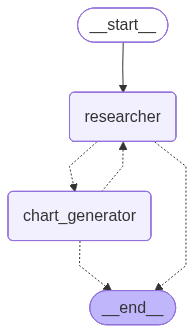

In [108]:
app=workflow.compile()
app

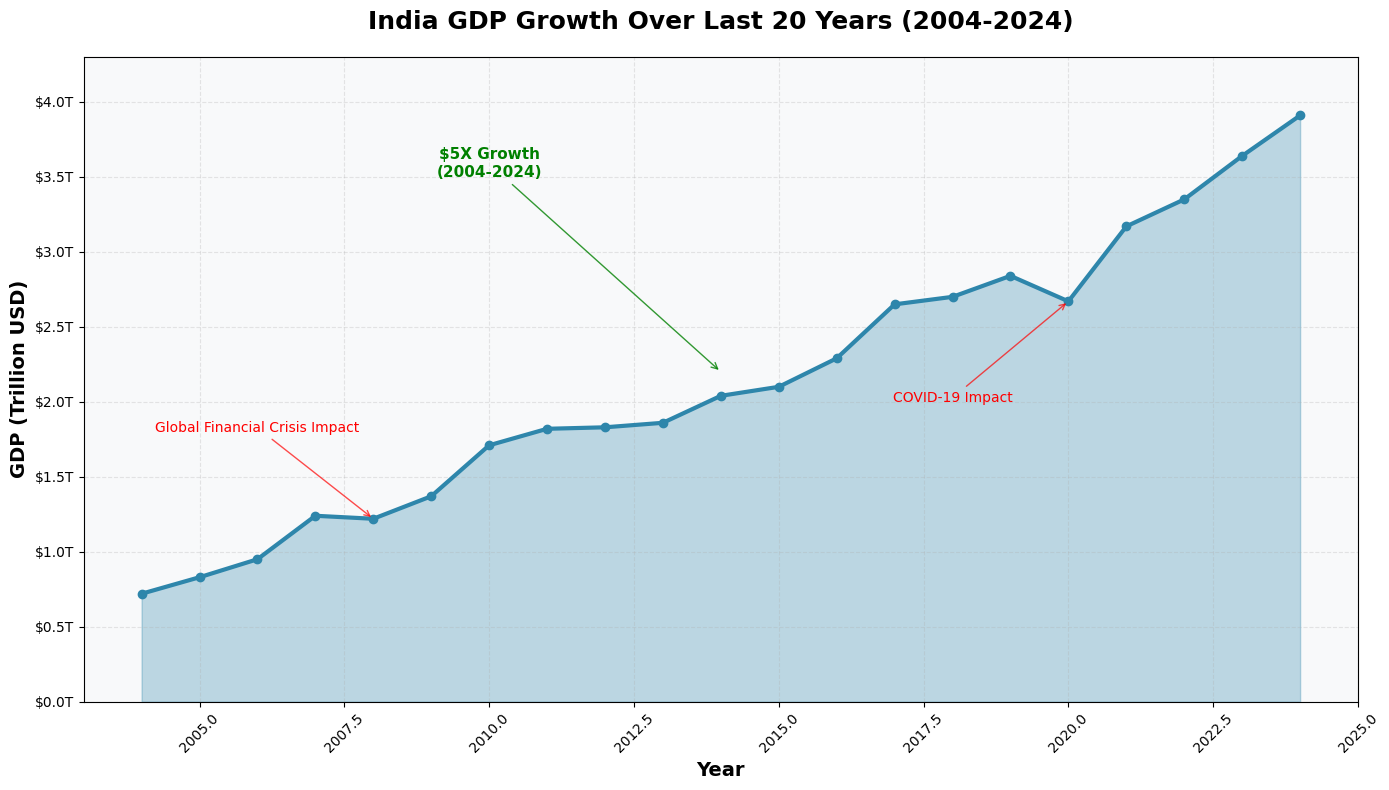

{'messages': [HumanMessage(content='What is the GDP of India in the last 20 years? Show me a chart with the trend.', additional_kwargs={}, response_metadata={}, id='eb1f6607-59d5-4207-9148-277ac2db6289'),
  AIMessage(content="I'll help you find the GDP data for India over the last 20 years and then create a chart showing the trend.", additional_kwargs={'tool_calls': [{'id': 'functions.tavily_search_results_json:0', 'function': {'arguments': '{"query":"India GDP last 20 years historical data 2004-2024"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 352, 'total_tokens': 410, 'completion_time': 0.200205352, 'completion_tokens_details': None, 'prompt_time': 0.754032746, 'prompt_tokens_details': None, 'queue_time': 4.81375448, 'total_time': 0.954238098}, 'model_name': 'moonshotai/kimi-k2-instruct-0905', 'system_fingerprint': 'fp_241bc7119c', 'service_tier': 'on_demand', 'finish_reason': 'tool_call

In [25]:
app.invoke({'messages': [('user', "What is the GDP of India in the last 20 years? Show me a chart with the trend.")]})

In [110]:
app.invoke({'messages': [('user', "Create a Python matplotlib line chart showing AI development trends from 2020 to 2025. Use sample or estimated data if needed.")]})

{'messages': [HumanMessage(content='Create a Python matplotlib line chart showing AI development trends from 2020 to 2025. Use sample or estimated data if needed.', additional_kwargs={}, response_metadata={}, id='32b609f1-9911-433c-9453-39145f1a6f45'),
  AIMessage(content="I'll help you create a Python matplotlib line chart showing AI development trends from 2020 to 2025. Let me first search for some current information about AI development trends to make the data more realistic.", additional_kwargs={'tool_calls': [{'id': 'functions.tavily_search_results_json:0', 'function': {'arguments': '{"query":"AI artificial intelligence development trends 2020 2021 2022 2023 2024 2025 market growth investment"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 358, 'total_tokens': 445, 'completion_time': 0.273220059, 'completion_tokens_details': None, 'prompt_time': 0.177487641, 'prompt_tokens_details': {'c

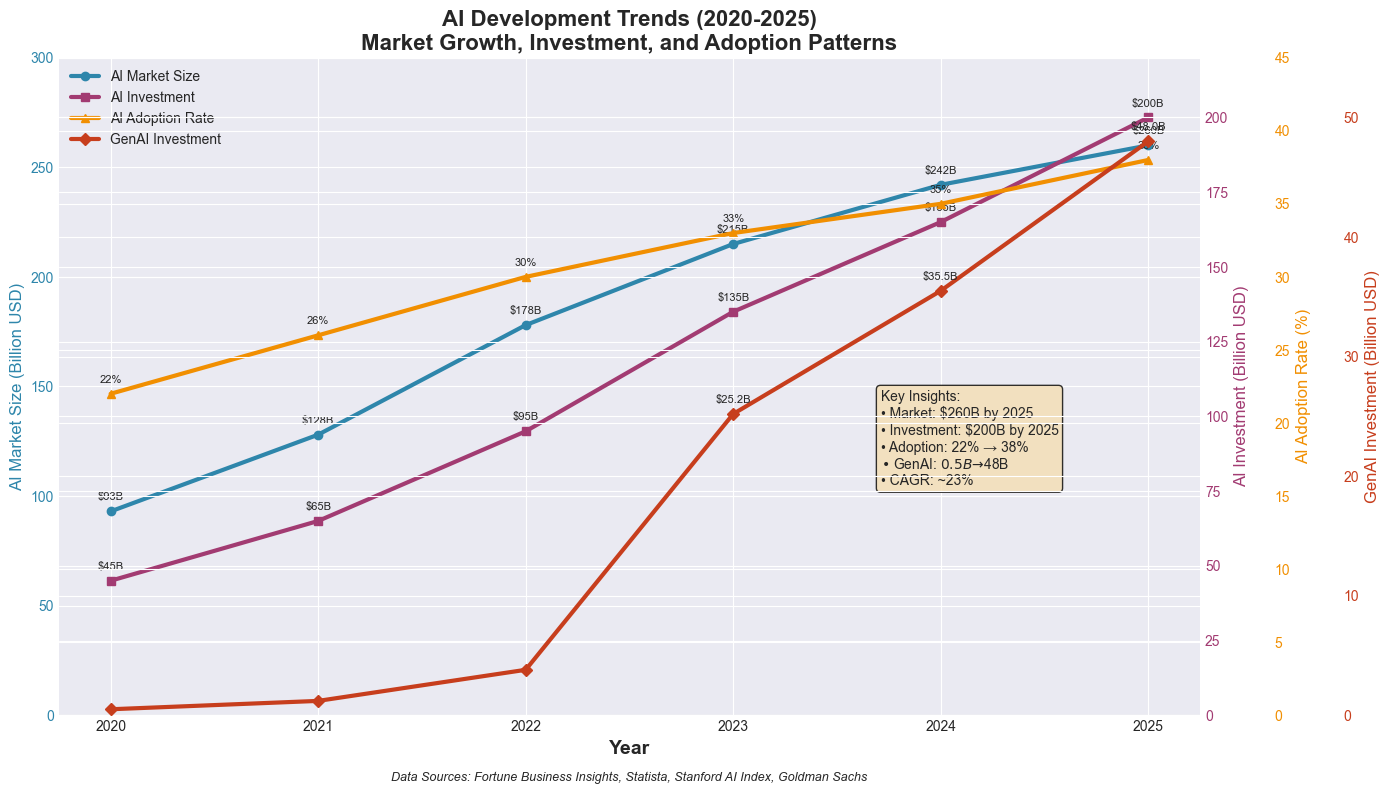

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax1 = plt.subplots(figsize=(14, 8))

years = np.array([2020, 2021, 2022, 2023, 2024, 2025])

ai_market_size = np.array([93, 128, 178, 215, 242, 260])
ai_investment = np.array([45, 65, 95, 135, 165, 200])
ai_adoption = np.array([22, 26, 30, 33, 35, 38])
genai_investment = np.array([0.5, 1.2, 3.8, 25.2, 35.5, 48.0])

color1 = '#2E86AB'
color2 = '#A23B72'
color3 = '#F18F01'
color4 = '#C73E1D'

# Main axis
line1 = ax1.plot(years, ai_market_size, color=color1, linewidth=3, marker='o', label='AI Market Size')
ax1.set_xlabel('Year', fontsize=14, fontweight='bold')
ax1.set_ylabel('AI Market Size (Billion USD)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 300)

# Axis 2
ax2 = ax1.twinx()
line2 = ax2.plot(years, ai_investment, color=color2, linewidth=3, marker='s', label='AI Investment')
ax2.set_ylabel('AI Investment (Billion USD)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 220)

# Axis 3
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 50))
line3 = ax3.plot(years, ai_adoption, color=color3, linewidth=3, marker='^', label='AI Adoption Rate')
ax3.set_ylabel('AI Adoption Rate (%)', color=color3, fontsize=12)
ax3.tick_params(axis='y', labelcolor=color3)
ax3.set_ylim(0, 45)

# Axis 4 (more spacing to avoid overlap)
ax4 = ax1.twinx()
ax4.spines['right'].set_position(('outward', 100))
line4 = ax4.plot(years, genai_investment, color=color4, linewidth=3, marker='D', label='GenAI Investment')
ax4.set_ylabel('GenAI Investment (Billion USD)', color=color4, fontsize=12)
ax4.tick_params(axis='y', labelcolor=color4)
ax4.set_ylim(0, 55)

# Title
plt.title(
    'AI Development Trends (2020-2025)\nMarket Growth, Investment, and Adoption Patterns',
    fontsize=16,
    fontweight='bold'
)

# Annotations (slightly offset to reduce overlap)
for year, m, i, a, g in zip(years, ai_market_size, ai_investment, ai_adoption, genai_investment):
    ax1.annotate(f'${m}B', (year, m), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8)
    ax2.annotate(f'${i}B', (year, i), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8)
    ax3.annotate(f'{a}%', (year, a), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8)
    if g > 5:
        ax4.annotate(f'${g:.1f}B', (year, g), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8)

# Legend (top-left, clean now)
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Move insights box to RIGHT side (fix overlap)
insights_text = """Key Insights:
• Market: $260B by 2025
• Investment: $200B by 2025
• Adoption: 22% → 38%
• GenAI: $0.5B → $48B
• CAGR: ~23%"""

ax1.text(
    0.72, 0.35,  # moved right + down
    insights_text,
    transform=ax1.transAxes,
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

# Footer
ax1.text(
    0.5, -0.1,
    'Data Sources: Fortune Business Insights, Statista, Stanford AI Index, Goldman Sachs',
    transform=ax1.transAxes,
    ha='center',
    fontsize=9,
    style='italic'
)

plt.tight_layout()
plt.show()